
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [13]:
import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "sentinel_00.tif"  # แก้ไข path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 2280, 'height': 1115, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(7.197731419613487e-05, 0.0, 102.8518581390381,
       0.0, -7.197731419613428e-05, 11.691994810274187)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


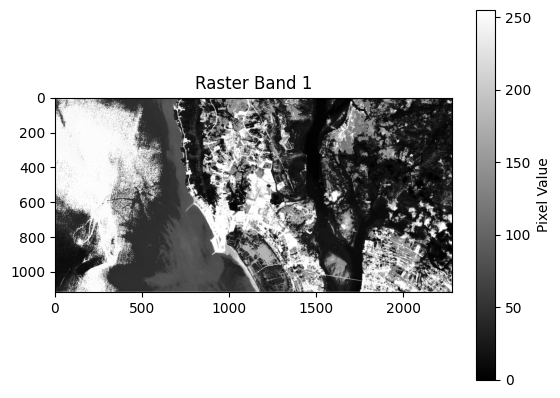

In [14]:
import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
# เนื่องจาก byte.tif มีเพียง 1 band จึงอ่าน band 1
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()


## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


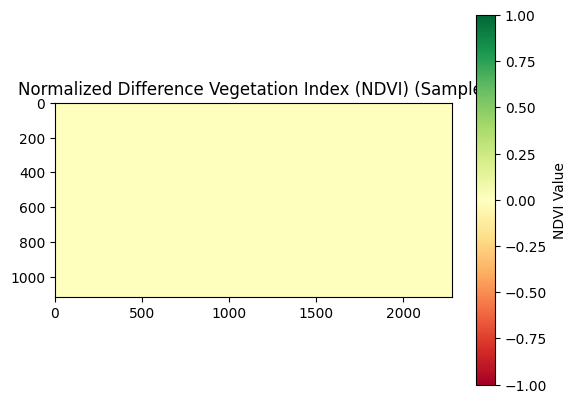

In [15]:
import numpy as np

# เปิดไฟล์ภาพดาวเทียม
# เนื่องจาก byte.tif มีเพียง 1 band จึงอาจไม่เหมาะสมกับการคำนวณ NDVI โดยตรง
# จะแสดงตัวอย่างโดยใช้ band เดียวที่มีอยู่
with rasterio.open(raster_path) as dataset:
    # สำหรับ byte.tif ซึ่งมี 1 band เราจะใช้ band เดียวกันสำหรับ NIR และ Red เพื่อให้โค้ดทำงานได้
    # ในการใช้งานจริง ควรใช้ภาพที่มีหลาย band และระบุ band ที่ถูกต้องสำหรับ NIR และ Red
    band_single = dataset.read(1).astype(float)
    nir = band_single # สมมติให้เป็น NIR
    red = band_single # สมมติให้เป็น Red (เพื่อไม่ให้เกิดข้อผิดพลาด, แต่ไม่ใช่การคำนวณ NDVI ที่ถูกต้อง)

# คำนวณ NDVI (จะเป็นค่า 0 หรือไม่นิยาม เนื่องจาก NIR == Red)
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI) (Sample)")
plt.show()


## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [16]:
# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    # ใช้ ndvi ที่คำนวณจากเซลล์ก่อนหน้า
    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")

บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [17]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
# เนื่องจากไม่มีไฟล์ shapefile 'boundary.shp' ในระบบ
# จึงไม่สามารถรันเซลล์นี้ได้โดยตรง
# หากต้องการรัน ต้องอัปโหลดไฟล์ shapefile หรือสร้าง geometry ด้วยมือ
print("ไม่สามารถรันเซลล์นี้ได้เนื่องจากไม่มีไฟล์ 'boundary.shp'")
# shapefile_path = "boundary.shp"  # ใส่ path ของไฟล์ขอบเขต
# gdf = gpd.read_file(shapefile_path)

# # แปลง Polygon เป็นรูปแบบ GeoJSON
# geometry = [mapping(gdf.geometry[0])]

# # ตัดภาพ Raster
# with rasterio.open(raster_path) as src:
#     out_image, out_transform = mask(src, geometry, crop=True)
#     out_meta = src.meta.copy()

# # อัปเดตเมตาดาต้าใหม่
# out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# # บันทึกไฟล์ที่ถูกตัด
# clipped_raster = "clipped_output.tif"
# with rasterio.open(clipped_raster, "w", **out_meta) as dest:
#     dest.write(out_image)

# print("ตัดข้อมูล Raster สำเร็จ!")

ไม่สามารถรันเซลล์นี้ได้เนื่องจากไม่มีไฟล์ 'boundary.shp'


# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

## Kernel State
Here are some of the notable variables in the kernel:
Variable #1
name: `raster_path`, type: `str`
value: `'byte.tif'`
Here are some of the files available in the kernel:
* /content/.config/.last_update_check.json
* /content/.config/default_configs.db
* /content/.config/active_config
* /content/.config/.last_opt_in_prompt.yaml
* /content/.config/.last_survey_prompt.yaml
* /content/.config/gce
* /content/.config/config_sentinel
* /content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
* /content/sample_data/README.md
* /content/sample_data/anscombe.json
* /content/sample_data/california_housing_test.csv
* /content/sample_data/mnist_train_small.csv
* /content/sample_data/mnist_test.csv
* /content/sample_data/california_housing_train.csv
* /content/.config/configurations/config_default
* /content/byte.tif

แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 2281, 'height': 1114, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(7.194949978612747e-05, 0.0, 102.78508186340333,
       0.0, -7.194949978612924e-05, 11.841226851592054)}


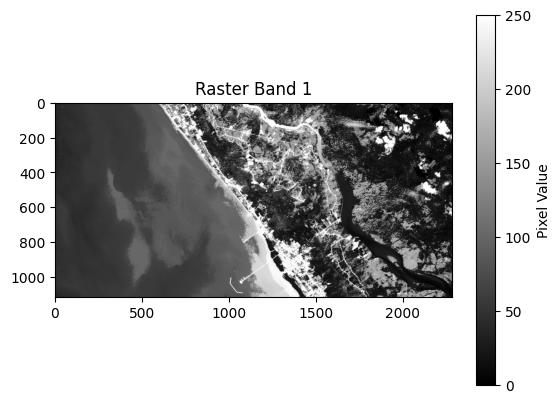

In [18]:
import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "sentinel_02.tif"  # แก้ไข path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
# เนื่องจาก byte.tif มีเพียง 1 band จึงอ่าน band 1
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()

แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [20]:
import rasterio

# ใช้ raster_path ที่ถูกกำหนดไว้ก่อนหน้านี้ หรือกำหนดใหม่หากต้องการ
raster_path = "/content/sentinel_02.tif" # ตรวจสอบให้แน่ใจว่าเป็น path ที่ถูกต้องของไฟล์ของคุณ

with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)

    # อธิบายค่าต่าง ๆ ใน metadata เพิ่มเติม
    print("\nคำอธิบายค่าเมตา:")
    print(f"  - Driver: {dataset.driver} (รูปแบบไฟล์ Raster)")
    print(f"  - dtype: {dataset.meta['dtype']} (ประเภทข้อมูลของแต่ละพิกเซล เช่น uint8, float32)")
    print(f"  - nodata: {dataset.nodata} (ค่าพิกเซลที่ถือว่าเป็น 'ไม่มีข้อมูล')")
    print(f"  - width: {dataset.width} (จำนวนพิกเซลในแนวนอน)")
    print(f"  - height: {dataset.height} (จำนวนพิกเซลในแนวตั้ง)")
    print(f"  - count: {dataset.count} (จำนวน Band หรือ Layer ของภาพ)")
    print(f"  - crs: {dataset.crs} (ระบบพิกัดอ้างอิงของภาพ - Coordinate Reference System)")
    print(f"  - transform: {dataset.transform} (เมตริกซ์แปลงพิกัดจากพิกเซลไปเป็นพิกัดโลก)")

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 2281, 'height': 1114, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(7.194949978612747e-05, 0.0, 102.78508186340333,
       0.0, -7.194949978612924e-05, 11.841226851592054)}

คำอธิบายค่าเมตา:
  - Driver: GTiff (รูปแบบไฟล์ Raster)
  - dtype: uint8 (ประเภทข้อมูลของแต่ละพิกเซล เช่น uint8, float32)
  - nodata: None (ค่าพิกเซลที่ถือว่าเป็น 'ไม่มีข้อมูล')
  - width: 2281 (จำนวนพิกเซลในแนวนอน)
  - height: 1114 (จำนวนพิกเซลในแนวตั้ง)
  - count: 1 (จำนวน Band หรือ Layer ของภาพ)
  - crs: EPSG:4326 (ระบบพิกัดอ้างอิงของภาพ - Coordinate Reference System)
  - transform: | 0.00, 0.00, 102.79|
| 0.00,-0.00, 1

แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

คำเตือน: ไฟล์มีจำนวน Band ไม่เพียงพอสำหรับการคำนวณ NDVI ที่ถูกต้อง, ใช้ Band เดียวกันสำหรับ NIR และ Red


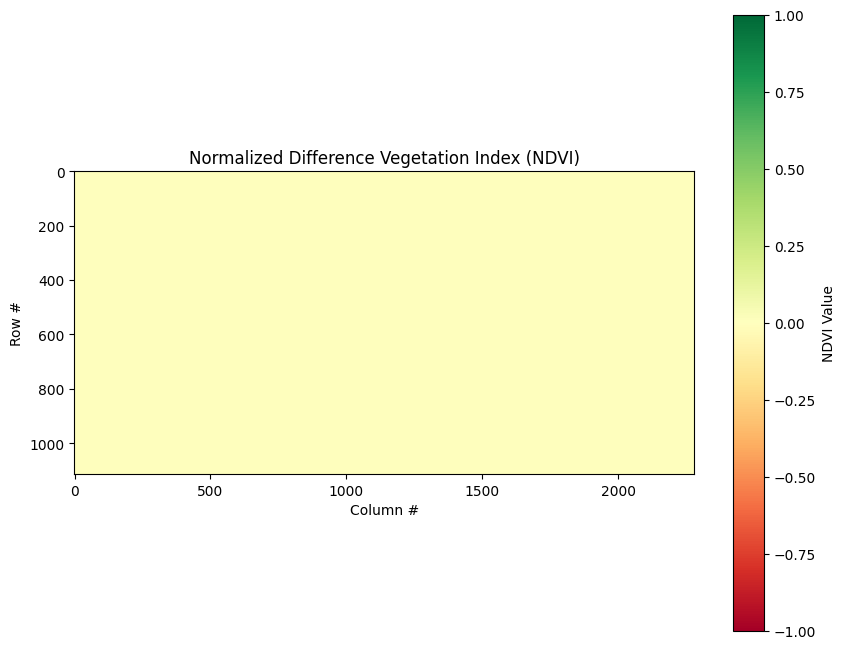

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

# ใช้ raster_path ที่ถูกกำหนดไว้ก่อนหน้านี้ (จากแบบฝึกหัด 1 และ 2)
# raster_path = "/content/sentinel_02.tif" # ไม่ต้องกำหนดซ้ำ ถ้า raster_path ยังคงเป็นค่าเดิมจากเซลล์ก่อนหน้า

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    # ตรวจสอบจำนวน Band ของภาพ
    num_bands = dataset.count

    if num_bands >= 2: # หากมีอย่างน้อย 2 Band สามารถคำนวณ NDVI ได้ดีขึ้น
        # สมมติ Band 1 เป็น Red และ Band 2 เป็น NIR เพื่อให้โค้ดทำงานได้กับไฟล์ที่มี 2 Band
        # ในความเป็นจริง ควรใช้ Band ที่ถูกต้องตามสเปกตรัมของภาพ (เช่น Sentinel-2: NIR=B8, Red=B4)
        red = dataset.read(1).astype(float)
        nir = dataset.read(2).astype(float)
        print("คำเตือน: การคำนวณ NDVI ใช้ Band 1 (Red) และ Band 2 (NIR) ซึ่งอาจไม่ถูกต้องตามสเปกตรัมของภาพจริง")
    else: # หากมีเพียง 1 Band จะใช้ Band เดียวกันสำหรับ NIR และ Red
        band_single = dataset.read(1).astype(float)
        nir = band_single # สมมติให้เป็น NIR
        red = band_single # สมมติให้เป็น Red
        print("คำเตือน: ไฟล์มีจำนวน Band ไม่เพียงพอสำหรับการคำนวณ NDVI ที่ถูกต้อง, ใช้ Band เดียวกันสำหรับ NIR และ Red")

# คำนวณ NDVI
# เพิ่มค่าคงที่ขนาดเล็ก (1e-10) เพื่อหลีกเลี่ยงการหารด้วยศูนย์
ndvi = (nir - red) / (nir + red + 1e-10)

# แสดงผล NDVI
plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()

แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

In [22]:
import geopandas as gpd
from shapely.geometry import Polygon
import os

# กำหนดพิกัดสำหรับสร้างขอบเขตสี่เหลี่ยมตัวอย่าง (ในระบบพิกัด WGS84)
# พิกัดเหล่านี้ถูกเลือกให้ครอบคลุมส่วนหนึ่งของภาพ sentinel_02.tif
# โดยอ้างอิงจาก transform ของภาพที่ระบุพิกัดเริ่มต้นประมาณ 102.78, 11.84
# และขนาดภาพ (width, height) 2281x1114 พิกเซล, pixel size ประมาณ 0.00007 องศา
# ทำให้ขอบเขตภาพอยู่ในช่วงประมาณลองจิจูด 102.78 ถึง 102.94 และละติจูด 11.76 ถึง 11.84

# สร้าง Polygon สำหรับขอบเขตการตัด
# ลองจิจูด x1, ละติจูด y1, ลองจิจูด x2, ละติจูด y2
minx, miny = 102.88, 11.78
maxx, maxy = 102.92, 11.82
boundary_polygon = Polygon([(minx, miny), (maxx, miny), (maxx, maxy), (minx, maxy), (minx, miny)])

# สร้าง GeoDataFrame
# CRS (Coordinate Reference System) ต้องตรงกับภาพ Raster (EPSG:4326)
gdf = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[boundary_polygon])

# กำหนดชื่อไฟล์ Shapefile
shapefile_path = "/content/boundary.shp"

# บันทึกเป็นไฟล์ Shapefile
gdf.to_file(shapefile_path)

print(f"สร้างไฟล์ Shapefile ตัวอย่าง '{shapefile_path}' เรียบร้อยแล้ว:")
print(gdf)

สร้างไฟล์ Shapefile ตัวอย่าง '/content/boundary.shp' เรียบร้อยแล้ว:
                                            geometry
0  POLYGON ((102.88 11.78, 102.92 11.78, 102.92 1...


หลังจากสร้างไฟล์ `boundary.shp` แล้ว จะตัดภาพ Raster `sentinel_02.tif` ด้วยขอบเขตที่กำหนดใน Shapefile นั้น

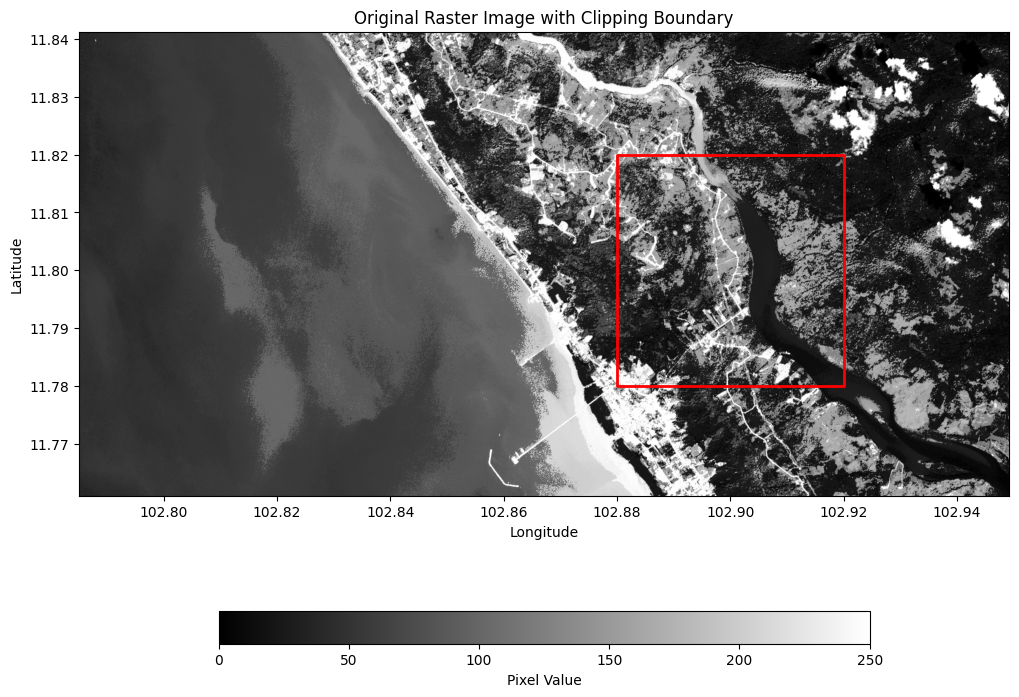

In [25]:
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterio.plot import plotting_extent # แก้ไข: เพิ่มการ import plotting_extent

# โหลดไฟล์ Raster ต้นฉบับ
raster_path = "/content/sentinel_02.tif"
with rasterio.open(raster_path) as src:
    original_image = src.read(1) # อ่าน band แรก
    transform = src.transform
    crs = src.crs

# โหลดไฟล์ Shapefile ของขอบเขตที่ใช้ตัด
shapefile_path = "/content/boundary.shp"
gdf = gpd.read_file(shapefile_path)

plt.figure(figsize=(12, 10))

# แสดงภาพ Raster ต้นฉบับ
plt.imshow(original_image, cmap='gray', extent=plotting_extent(src)) # แก้ไข: เรียกใช้ plotting_extent โดยตรง
plt.title("Original Raster Image with Clipping Boundary")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# วาดขอบเขตของ Shapefile ทับลงไปบนภาพ Raster
gdf.plot(ax=plt.gca(), facecolor='none', edgecolor='red', linewidth=2)

plt.colorbar(label="Pixel Value", orientation='horizontal', shrink=0.7)
plt.show()

ภาพที่ได้จากการตัด

ตัดข้อมูล Raster สำเร็จ! บันทึกที่: /content/clipped_sentinel_02.tif


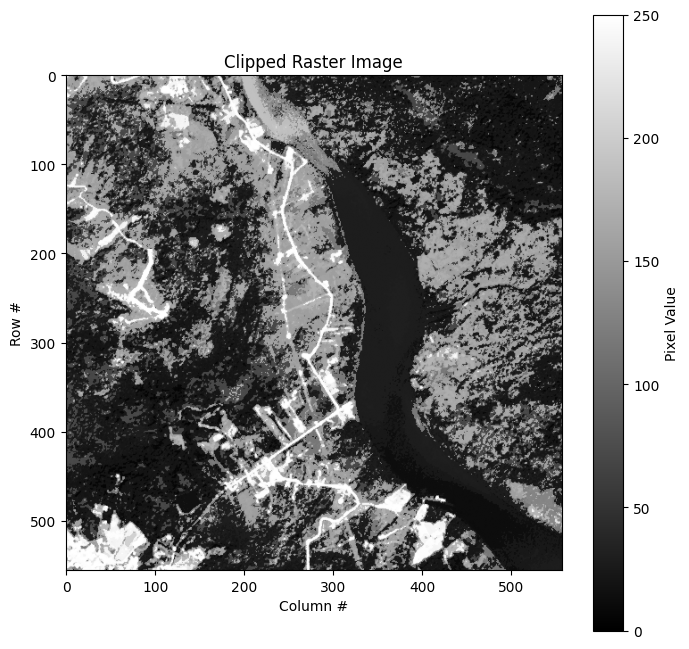

In [26]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt

# ใช้ raster_path ที่ถูกกำหนดไว้ก่อนหน้านี้
raster_path = "/content/sentinel_02.tif" # ตรวจสอบให้แน่ใจว่าเป็น path ที่ถูกต้องของไฟล์ของคุณ
shapefile_path = "/content/boundary.shp" # ใช้ไฟล์ shapefile ที่สร้างขึ้น

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON เพื่อใช้กับ rasterio.mask
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่สำหรับภาพที่ถูกตัด
out_meta.update({"height": out_image.shape[1],
                  "width": out_image.shape[2],
                  "transform": out_transform,
                  "nodata": 0}) # กำหนดค่า nodata เป็น 0 หรือค่าที่เหมาะสมหากมีพื้นหลังสีดำ

# บันทึกไฟล์ที่ถูกตัด
clipped_raster_output_path = "/content/clipped_sentinel_02.tif"
with rasterio.open(clipped_raster_output_path, "w", **out_meta) as dest:
    dest.write(out_image)

print(f"ตัดข้อมูล Raster สำเร็จ! บันทึกที่: {clipped_raster_output_path}")

# แสดงภาพ Raster ที่ถูกตัดแล้ว
plt.figure(figsize=(8, 8))
plt.imshow(out_image[0], cmap='gray') # แสดง band แรก (หรือ band เดียว) ของภาพที่ตัดแล้ว
plt.title("Clipped Raster Image")
plt.colorbar(label="Pixel Value")
plt.xlabel("Column #")
plt.ylabel("Row #")
plt.show()